In [1]:
pip install rouge-score pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
reference_dir = "/Users/senudaliyanage/Downloads/IIT/Final Year Project/Legal Document Summarization/results/openai_results/openai_summaries_test_merged"
model_dir = "/Users/senudaliyanage/Downloads/IIT/Final Year Project/Legal Document Summarization/results/dpo_mistral24B_results/dpo_mistral24B_summaries_test_merged"

In [4]:
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

In [5]:
results = []

for file in os.listdir(reference_dir):

    if not file.endswith(".txt"):
        continue
        
    ref_path = os.path.join(reference_dir, file)
    model_path = os.path.join(model_dir, file)

    if not os.path.exists(model_path):
        continue

    with open(ref_path) as f:
        reference = f.read()

    with open(model_path) as f:
        prediction = f.read()

    scores = scorer.score(reference, prediction)

    results.append({
        "document": file,
        "rouge1": scores["rouge1"].fmeasure,
        "rouge2": scores["rouge2"].fmeasure,
        "rougeL": scores["rougeL"].fmeasure
    })

df = pd.DataFrame(results)

df.head()

,document,rouge1,rouge2,rougeL
0,2019-08-20-56.txt,0.520000,0.242424,0.380000
1,2017-08-08-223.txt,0.418314,0.193952,0.235172
2,2015-09-22-78.txt,0.412098,0.151803,0.185255
3,2007-02-09-05.txt,0.322267,0.173560,0.210526
4,2013-03-08-08.txt,0.524173,0.306905,0.269720


In [6]:
mean_scores = df[["rouge1","rouge2","rougeL"]].mean()

print("Mean ROUGE scores:")
print(mean_scores)

Mean ROUGE scores:
rouge1    0.454864
rouge2    0.227038
rougeL    0.270706
dtype: float64


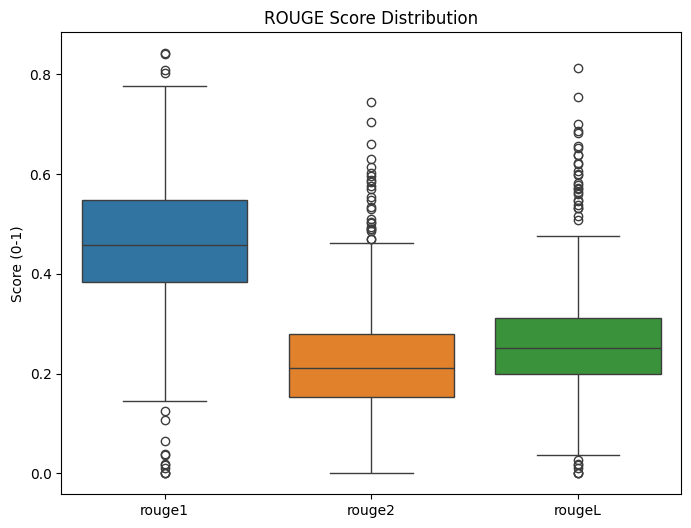

In [7]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df[["rouge1","rouge2","rougeL"]])

plt.title("ROUGE Score Distribution")
plt.ylabel("Score (0-1)")
plt.show()

In [8]:
score_cols = ["rouge1", "rouge2", "rougeL"]

Q1 = df[score_cols].quantile(0.25)
Q3 = df[score_cols].quantile(0.75)

IQR = Q3 - Q1

In [9]:
df_clean = df[~(
    (df[score_cols] < (Q1 - 1.5 * IQR)) |
    (df[score_cols] > (Q3 + 1.5 * IQR))
).any(axis=1)]

In [10]:
df_clean[score_cols].mean()

rouge1    0.446238
rouge2    0.209079
rougeL    0.252722
dtype: float64

In [11]:
print("Original docs:", len(df))
print("After outlier removal:", len(df_clean))

Original docs: 438
After outlier removal: 396
